# AIFI - Tennessee Eastman smart-factory predictive engine

An end-to-end notebook walkthrough for the **AIFI** (AI Fault Intelligence) prototype. Every cell calls into the modules under `src/` so the notebook stays a thin demo layer rather than a duplicate codebase.

## Industrial context

The Tennessee Eastman Process (TEP) is the *de facto* benchmark for chemical-plant fault detection. We frame the problem as an **Industry 4.0 predictive-maintenance platform** for a smart chemical plant:

* 41 process measurements + 11 manipulated variables sampled every 3 minutes
* 21 plant states: 1 normal + 20 documented faults
* outputs feed an animated dashboard (Next.js) via the FastAPI service in `api/main.py`

## Pipeline sections

1. **Data loading** - parquet cache + balanced sub-sampling
2. **Preprocessing** - imputation, scaling, missing-value & outlier audit
3. **EDA** - class distribution, correlation heatmap, sensor trends, PCA
4. **Model training** - Random Forest + XGBoost
5. **Evaluation** - accuracy, precision, recall, F1, confusion matrix
6. **Explainability** - native importances + SHAP
7. **Smart-factory simulation** - structured alerts ready for the dashboard

In [1]:
import sys, logging
from pathlib import Path

# Make sure the project root is on the path when running from notebooks/
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

logging.basicConfig(level=logging.INFO, format='%(asctime)s | %(levelname)s | %(message)s')

from src import config
from src.data_loader import load_tep_dataset, stream_simulation_run
from src.preprocessing import preprocess_split
from src.eda import (plot_class_distribution, plot_correlation_heatmap,
                     plot_sensor_trends, plot_pca, plot_feature_variance)
from src.models import train_all
from src.evaluation import (evaluate_model, save_evaluation_report,
                            plot_model_comparison, pick_best_model)
from src.explainability import plot_feature_importance, compute_shap_summary
from src.simulation import build_alert, simulate_live_stream, generate_demo_alerts

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display
print('Project root:', config.PROJECT_ROOT)

Project root: C:\Users\LithiChang\groupAIFL\AIFI-group_project


## 1. Load the Tennessee Eastman dataset

The first call also builds a parquet cache from the raw `.RData` files (one-off, ~2 minutes). Subsequent calls just slice the cache and balance simulation runs per fault class.

In [2]:
# Reduce train_runs / test_runs for a quicker walkthrough; bump up for production runs.
ds = load_tep_dataset(train_runs_per_fault=20, test_runs_per_fault=10)
print('Summary:', ds.summary())
ds.class_distribution().head(25)

2026-05-09 13:20:36,825 | INFO | Loading parquet cache from C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\cache
2026-05-09 13:21:24,021 | INFO | Final shapes: X_train=(202000, 52) X_test=(169600, 52)


Summary: {'train_rows': 202000, 'test_rows': 169600, 'n_features': 52, 'n_classes': 21}


,train,test
faultNumber,,
0,10000,9600
1,9600,8000
2,9600,8000
3,9600,8000
4,9600,8000
5,9600,8000
6,9600,8000
7,9600,8000
8,9600,8000


## 2. Preprocess the sensor stream

* schema check (missing / extra TEP tags),
* median imputation (robust to sensor drop-outs),
* StandardScaler (fitted on train only - no leakage),
* outlier audit (`|z| > 6`).

In [3]:
X_train_p, X_test_p, artifacts, audit = preprocess_split(ds.X_train, ds.X_test)
print('Train missing rate (top 5):')
print(audit['missing_train'].head())
print('\nOutlier audit (top 5 sensors):')
print(audit['outliers_train'].head())

2026-05-09 13:21:25,840 | INFO | Preprocessing complete: train=(202000, 52) test=(169600, 52)


Train missing rate (top 5):
         missing_rate
xmeas_1           0.0
xmeas_2           0.0
xmeas_3           0.0
xmeas_4           0.0
xmeas_5           0.0

Outlier audit (top 5 sensors):
          outlier_count  outlier_rate
xmv_5              4086       0.02023
xmv_10             3000       0.01485
xmv_2              2488       0.01232
xmv_1              1922       0.00951
xmeas_21           1630       0.00807


## 3. Exploratory data analysis

Every plot is also saved under `outputs/figures/` so it can be embedded in the dashboard.

In [4]:
plot_class_distribution(ds.y_train, ds.y_test); plt.show()
plot_correlation_heatmap(X_train_p);            plt.show()
plot_sensor_trends(X_train_p, ds.meta_train, ds.y_train); plt.show()
plot_pca(X_train_p, ds.y_train);                plt.show()
plot_feature_variance(X_train_p);               plt.show()

2026-05-09 13:21:26,253 | INFO | Saved figure C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\figures\01_class_distribution.png
2026-05-09 13:21:27,347 | INFO | Saved figure C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\figures\02_correlation_heatmap.png
2026-05-09 13:21:27,658 | INFO | Saved figure C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\figures\03_sensor_trends.png
2026-05-09 13:21:27,910 | INFO | Saved figure C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\figures\04_pca_scatter.png
2026-05-09 13:21:28,255 | INFO | Saved figure C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\figures\05_feature_variance.png


## 4. Train Random Forest + XGBoost

In [5]:
trained = train_all(['random_forest', 'xgboost'], X_train_p, ds.y_train, artifacts)
for m in trained.values():
    m.save()
    print(f'{m.name}: trained in {m.train_time_s:.1f}s, {len(m.classes_)} classes')

2026-05-09 13:21:28,267 | INFO | Training random_forest on X=(202000, 52) y=(202000,) (21 classes)…
2026-05-09 13:21:47,193 | INFO | Trained random_forest in 18.9s
2026-05-09 13:21:47,245 | INFO | Training xgboost on X=(202000, 52) y=(202000,) (21 classes)…
2026-05-09 13:23:29,293 | INFO | Trained xgboost in 102.0s
2026-05-09 13:23:29,585 | INFO | Saved random_forest -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\models\random_forest.joblib


random_forest: trained in 18.9s, 21 classes


2026-05-09 13:23:29,974 | INFO | Saved xgboost -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\models\xgboost.joblib


xgboost: trained in 102.0s, 21 classes


## 5. Evaluate on the held-out TEP testing set

In [6]:
results = [evaluate_model(m, ds.X_test, ds.y_test) for m in trained.values()]
summary = pd.DataFrame([r.to_summary() for r in results]).set_index('model')
summary

2026-05-09 13:23:33,552 | INFO | [random_forest] acc=0.7199 prec_macro=0.7699 rec_macro=0.7260 f1_macro=0.7355 f1_weighted=0.7296
2026-05-09 13:23:35,615 | INFO | [xgboost] acc=0.7850 prec_macro=0.8148 rec_macro=0.7900 f1_macro=0.8008 f1_weighted=0.7956


,accuracy,precision_macro,recall_macro,f1_macro,f1_weighted,train_time_s
model,,,,,,
random_forest,0.7199,0.7699,0.726,0.7355,0.7296,18.92
xgboost,0.7850,0.8148,0.790,0.8008,0.7956,102.05


In [7]:
plot_model_comparison(results); plt.show()
save_evaluation_report(results)
best = pick_best_model(results)
print(f'Best model: {best.name}  (f1_macro={best.f1_macro:.4f})')
best_model = trained[best.name]

2026-05-09 13:23:35,739 | INFO | Saved metrics report -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\reports\model_metrics.json


Best model: xgboost  (f1_macro=0.8008)


## 6. Explainability

Native importances are cheap; SHAP gives a class-aware view but is much slower.

## 7. Smart-factory simulation

Stream a single TEP simulation through the model and inspect the structured Industry 4.0 alert. This is exactly what the FastAPI service in `api/main.py` returns to the Next.js dashboard.

In [8]:
plot_feature_importance(best_model, top_n=20); plt.show()

2026-05-09 13:23:36,075 | INFO | Saved feature-importance plot C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\figures\feature_importance_xgboost.png and table C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\reports\feature_importance_xgboost.csv


2026-05-09 13:23:37,307 | INFO | Computing SHAP values on 500 samples (this can take a minute)…
2026-05-09 13:23:42,369 | INFO | Saved SHAP summary plot C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\figures\shap_summary_xgboost.png and table C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\reports\shap_importance_xgboost.csv


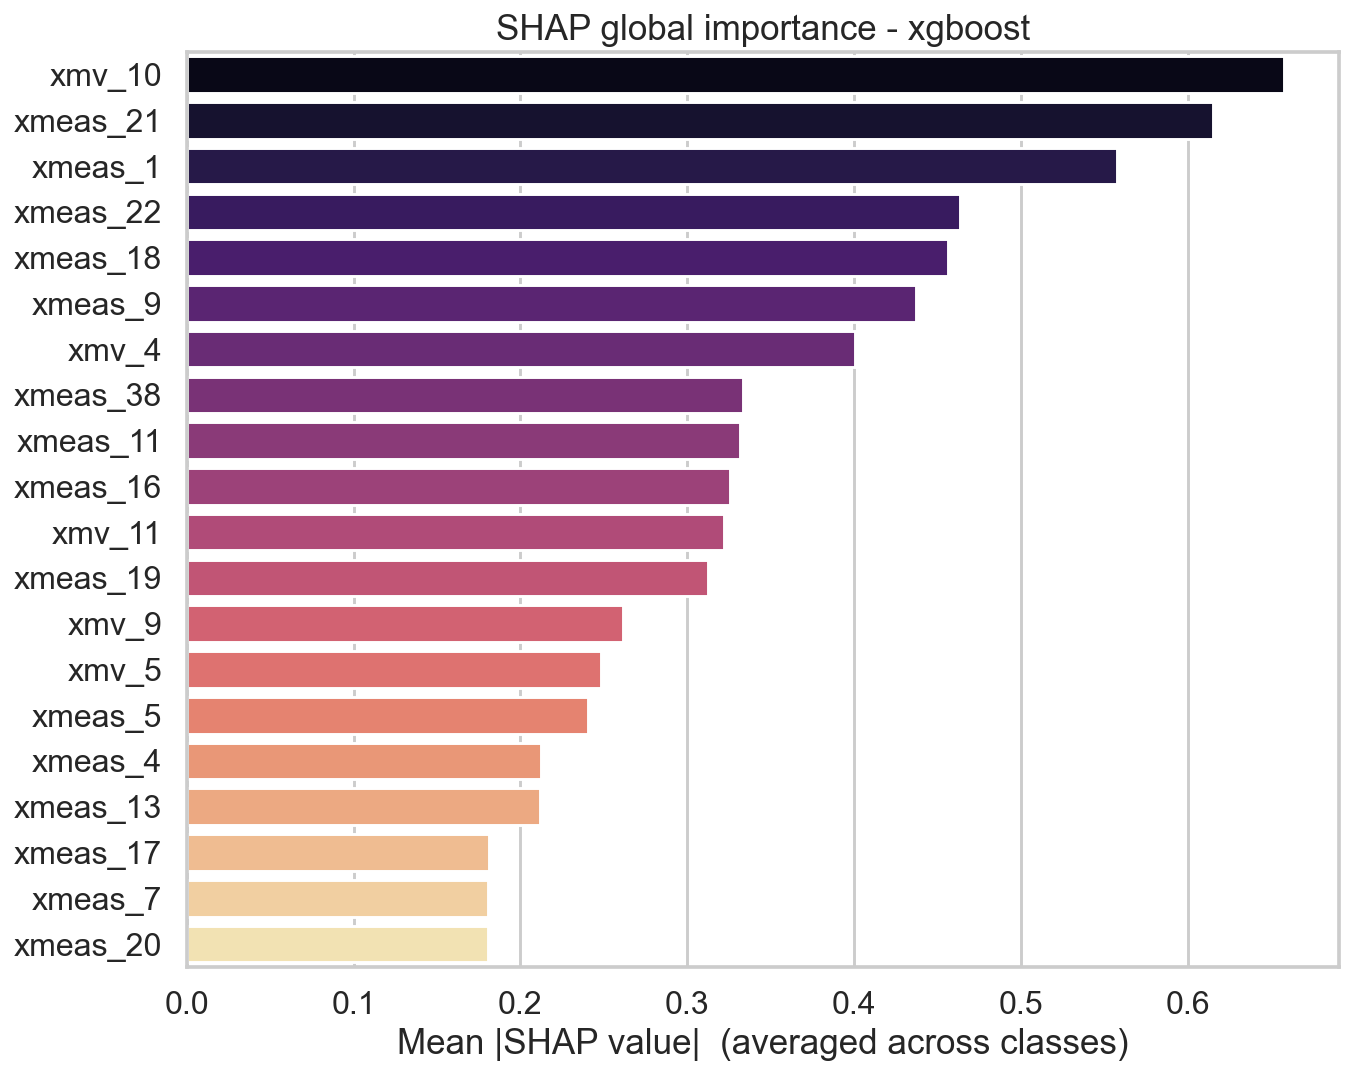

In [9]:
compute_shap_summary(best_model, X_test_p, sample_size=500)
display(Image(filename=str(config.FIGURE_DIR / f'shap_summary_{best_model.name}.png')))

In [10]:
features, meta = stream_simulation_run(fault_number=4, split='testing', random_state=7)
alert = build_alert(features.iloc[300], best_model,
                    sample_index=int(meta['sample'].iloc[300]),
                    simulation_run=int(meta['simulationRun'].iloc[0]),
                    ground_truth=int(meta['faultNumber'].iloc[0]))
print(alert.pretty())
print('\nTop contributing sensors:')
for f in alert.top_features:
    print(f"  {f['feature']:>8s}  z={f['z_score']:+.2f}  contrib={f['contribution']:+.4f}")

Plant Status:        ALERT
Predicted Fault:     Reactor Cooling Inlet Temperature Step
Confidence:          98.3%
Severity:            HIGH
Recommended Action:  Inspect reactor cooling water supply, heat-exchanger fouling, cooling tower.

Top contributing sensors:
   xmeas_1  z=+0.39  contrib=+0.0482
   xmeas_5  z=-1.39  contrib=-0.0406
     xmv_4  z=-0.42  contrib=-0.0282
    xmv_10  z=+0.39  contrib=+0.0264
  xmeas_10  z=-0.25  contrib=-0.0135


In [11]:
# Generate dashboard-ready demo streams (one JSON per fault, written to outputs/predictions/)
paths = generate_demo_alerts(best_model, fault_ids=(0, 1, 4, 6, 11, 14), sample_every=20)
for p in paths:
    print(p)

2026-05-09 13:23:51,802 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_00_run_426.json
2026-05-09 13:23:56,341 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_01_run_426.json
2026-05-09 13:24:01,108 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_04_run_426.json
2026-05-09 13:24:05,887 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_06_run_426.json
2026-05-09 13:24:10,809 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_11_run_426.json
2026-05-09 13:24:15,446 | INFO | Wrote 48 alerts -> C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_14_run_426.json


C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_00_run_426.json
C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_01_run_426.json
C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_04_run_426.json
C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_06_run_426.json
C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_11_run_426.json
C:\Users\LithiChang\groupAIFL\AIFI-group_project\outputs\predictions\stream_fault_14_run_426.json


## Next steps

* `uvicorn api.main:app --reload --port 8000` exposes `/predict`, `/simulate/{fault_id}`, `/metrics` and the demo streams via REST.
* The Next.js dashboard can fetch `/demo/stream_fault_04_run_*.json` to drive an animated reactor view.
* Re-run `python -m src.pipeline --help` for all CLI options.